# Task-02: K-Means Clustering for Customer Segmentation

**Goal:** Group mall customers into segments based on purchase behavior (Annual Income & Spending Score) using K-Means clustering.

**Dataset:** Mall_Customers.csv (200 customers)


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
%matplotlib inline

#  Load & Explore the Data

In [31]:
df = pd.read_csv("/Users/niteshssr/PRODIGY_ML_02/Mall_Customers.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [32]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [33]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

#  Select & Scale Features

We cluster on **Annual Income** and **Spending Score** — the two variables that directly capture purchase behavior. Since K-Means is distance-based, we standardize them first so one feature doesn't dominate due to scale.

In [34]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find the Optimal Number of Clusters (Elbow Method + Silhouette Score)

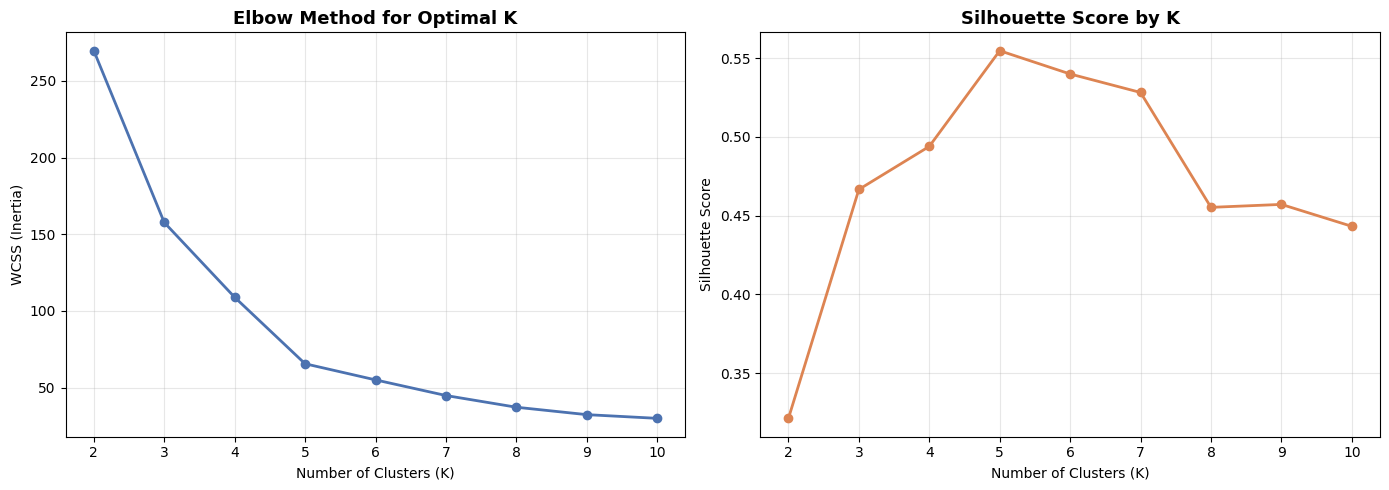

Silhouette scores: {2: 0.321, 3: 0.467, 4: 0.494, 5: 0.555, 6: 0.54, 7: 0.528, 8: 0.455, 9: 0.457, 10: 0.443}
Best K by silhouette score: 5


In [35]:
wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), wcss, marker='o', color='#4C72B0', linewidth=2)
axes[0].set_title('Elbow Method for Optimal K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), sil_scores, marker='o', color='#DD8452', linewidth=2)
axes[1].set_title('Silhouette Score by K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k_by_sil = list(K_range)[int(np.argmax(sil_scores))]
print(f"Silhouette scores: {dict(zip(K_range, [round(s,3) for s in sil_scores]))}")
print(f"Best K by silhouette score: {best_k_by_sil}")

In [36]:
# The elbow bends around K=5, and K=5 also gives the highest silhouette score

# Fit the Final K-Means Model

In [37]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['Cluster'])
print(f"Final model: K={OPTIMAL_K}, Silhouette Score={sil:.3f}")

centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df.round(1)

Final model: K=5, Silhouette Score=0.555


,Annual Income (k$),Spending Score (1-100)
0,55.3,49.5
1,86.5,82.1
2,25.7,79.4
3,88.2,17.1
4,26.3,20.9


# Visualize the Clusters

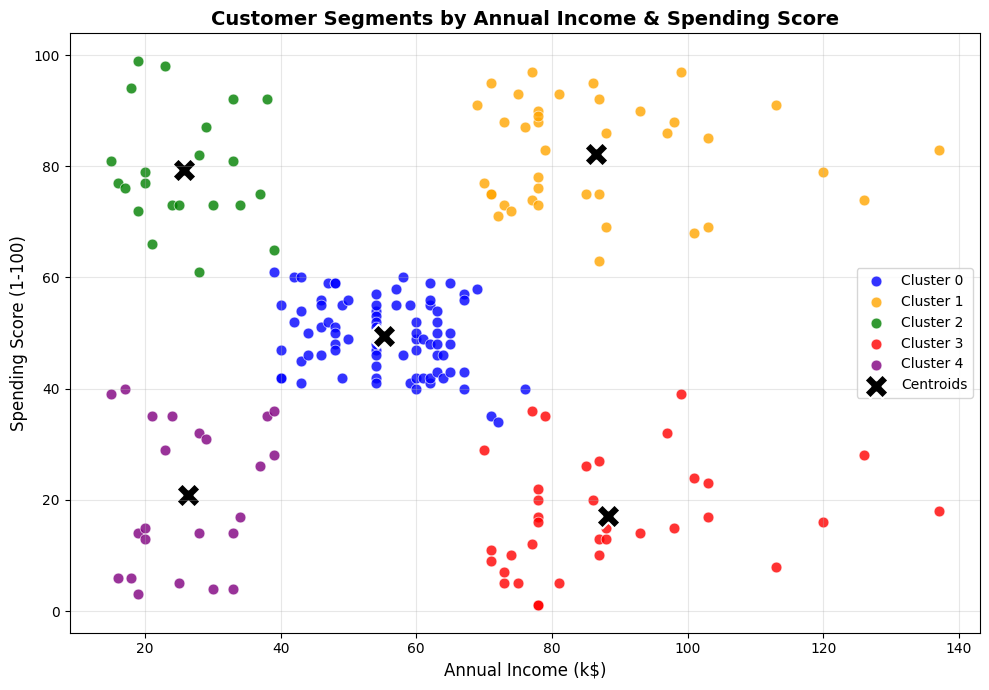

In [38]:
import matplotlib.pyplot as plt

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

plt.figure(figsize=(10, 7))

for i in range(OPTIMAL_K):
    cluster_data = df[df['Cluster'] == i]

    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        s=60,
        color=colors[i],
        label=f'Cluster {i}',
        alpha=0.8,
        edgecolors='white',
        linewidth=0.5
    )

# Plot centroids
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    s=300,
    color='black',
    marker='X',
    label='Centroids',
    edgecolors='white',
    linewidth=1.5
)

plt.title('Customer Segments by Annual Income & Spending Score',
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Profile & Label Each Segment

In [39]:
profile = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean'),
).round(1)

profile

,Count,Avg_Age,Avg_Income,Avg_Spending
Cluster,,,,
0,81,42.7,55.3,49.5
1,39,32.7,86.5,82.1
2,22,25.3,25.7,79.4
3,35,41.1,88.2,17.1
4,23,45.2,26.3,20.9


In [40]:
income_mean = centers_df['Annual Income (k$)'].mean()
spend_mean = centers_df['Spending Score (1-100)'].mean()

def label_cluster(row):
    inc = row['Annual Income (k$)']
    spend = row['Spending Score (1-100)']
    if abs(inc - income_mean) < 12 and abs(spend - spend_mean) < 12:
        return "Standard (Avg Income, Avg Spending)"
    elif inc >= income_mean and spend >= spend_mean:
        return "Target (High Income, High Spending)"
    elif inc >= income_mean and spend < spend_mean:
        return "Careful (High Income, Low Spending)"
    elif inc < income_mean and spend >= spend_mean:
        return "Careless (Low Income, High Spending)"
    else:
        return "Sensible (Low Income, Low Spending)"

centers_df['Segment'] = centers_df.apply(label_cluster, axis=1)
centers_df.round(1)

,Annual Income (k$),Spending Score (1-100),Segment
0,55.3,49.5,"Standard (Avg Income, Avg Spending)"
1,86.5,82.1,"Target (High Income, High Spending)"
2,25.7,79.4,"Careless (Low Income, High Spending)"
3,88.2,17.1,"Careful (High Income, Low Spending)"
4,26.3,20.9,"Sensible (Low Income, Low Spending)"


# Correlation Heatmap

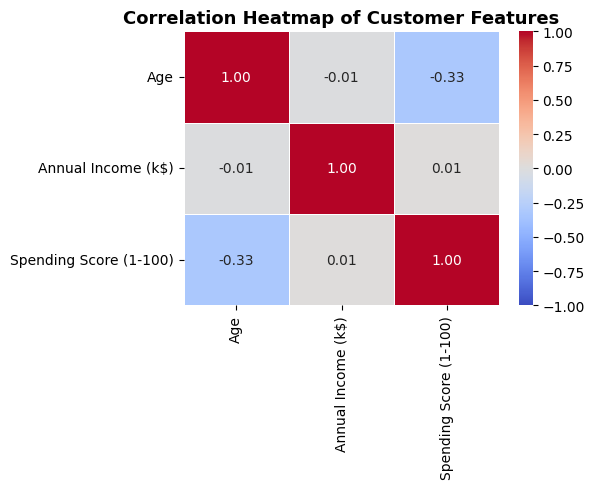

In [41]:
import seaborn as sns

numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Customer Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Gender Distribution per Cluster

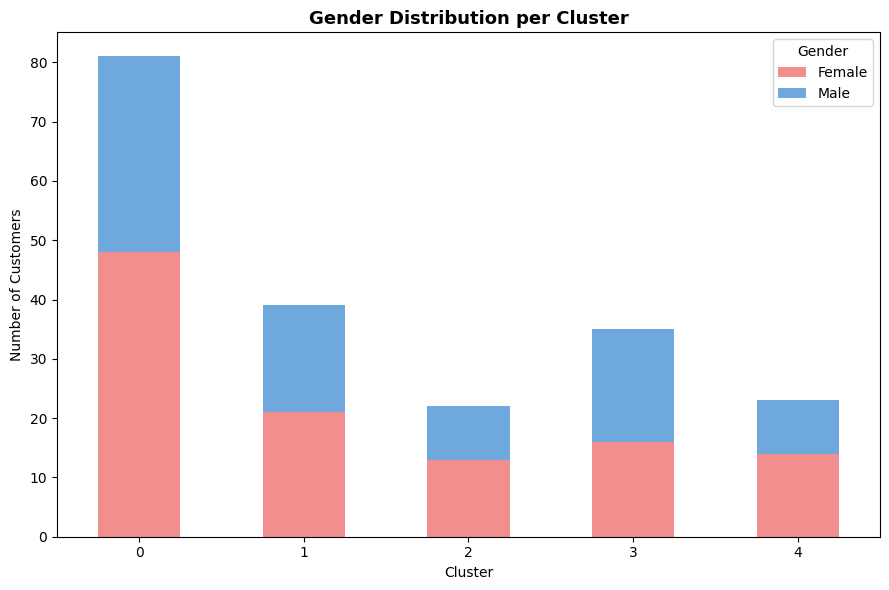

Gender,Female,Male
Cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


In [42]:
gender_counts = df.groupby(['Cluster', 'Gender']).size().unstack(fill_value=0)

gender_counts.plot(kind='bar', stacked=True, figsize=(9, 6), color=['#F28E8E', '#6FA8DC'])
plt.title('Gender Distribution per Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

gender_counts

# Age Distribution per Cluster

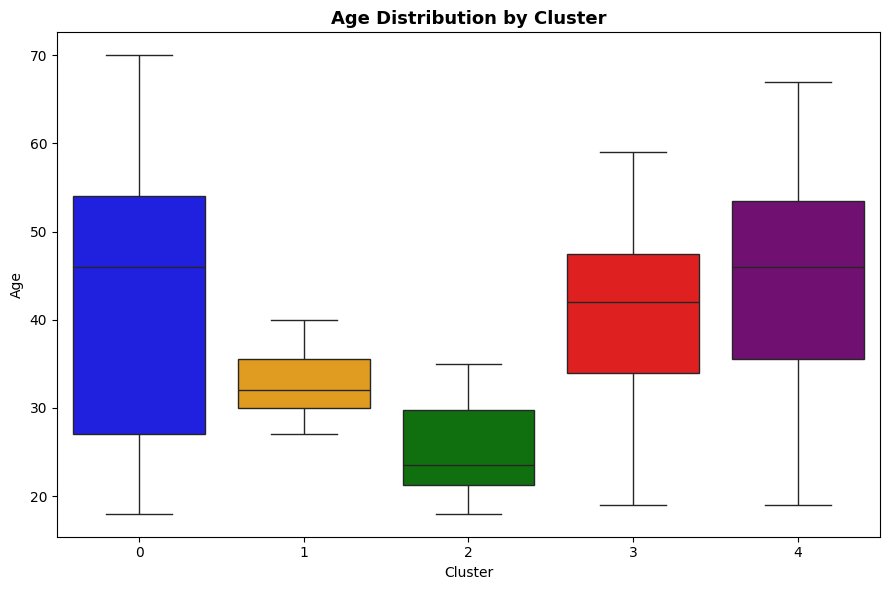

In [43]:
plt.figure(figsize=(9, 6))
sns.boxplot(x='Cluster', y='Age', data=df, hue='Cluster', palette=colors[:OPTIMAL_K], legend=False)
plt.title('Age Distribution by Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

# Cluster Size Distribution

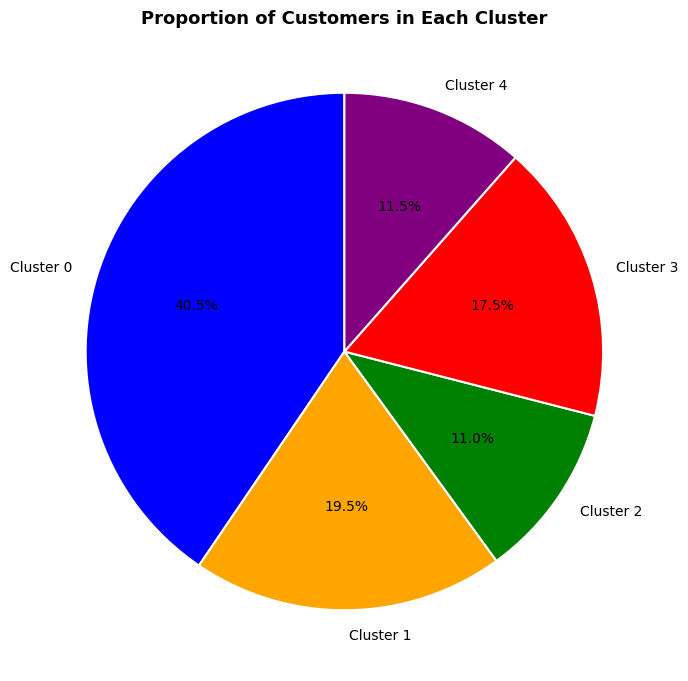

In [44]:
import matplotlib.pyplot as plt

cluster_sizes = df['Cluster'].value_counts().sort_index()

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

plt.figure(figsize=(7, 7))

plt.pie(
    cluster_sizes,
    labels=[f'Cluster {i}' for i in cluster_sizes.index],
    autopct='%1.1f%%',
    colors=colors[:len(cluster_sizes)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Proportion of Customers in Each Cluster',
          fontsize=13,
          fontweight='bold')

plt.axis('equal')   # Makes the pie chart perfectly circular
plt.tight_layout()
plt.show()

# 3D Cluster Plot (Age, Income, Spending Score)

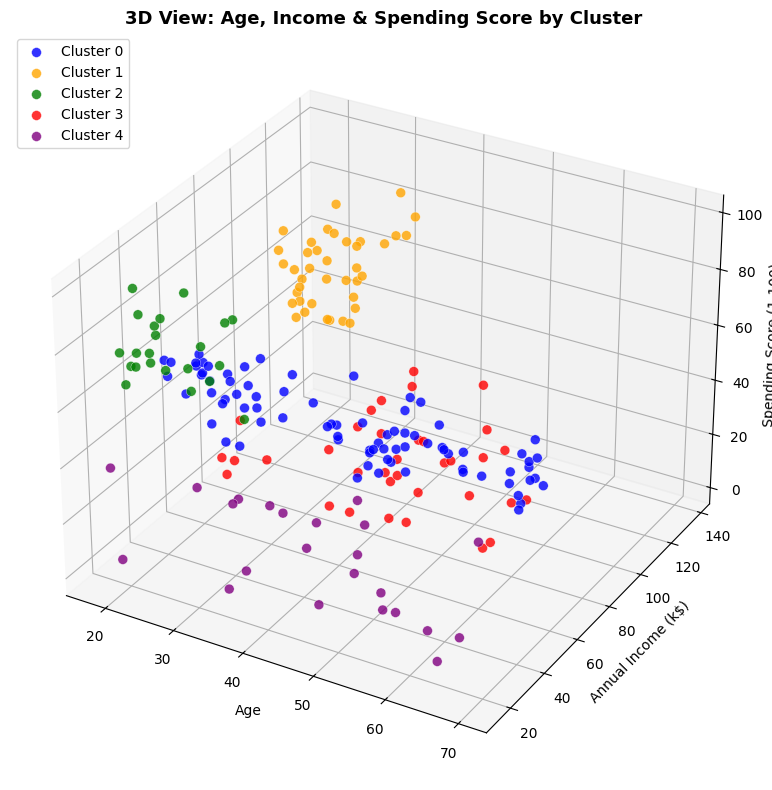

In [45]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(OPTIMAL_K):
    cluster_data = df[df['Cluster'] == i]
    ax.scatter(cluster_data['Age'], cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
               s=50, c=colors[i], label=f'Cluster {i}', alpha=0.8, edgecolors='white', linewidth=0.3)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D View: Age, Income & Spending Score by Cluster', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Save Result 

In [46]:
df.to_csv('Mall_Customers_Clustered.csv', index=False)
print("Saved: Mall_Customers_Clustered.csv")
df.head()

Saved: Mall_Customers_Clustered.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# Save Images 

In [ ]:
import os
import matplotlib.pyplot as plt

# Create output folder
SAVE_DIR = "output_images"
os.makedirs(SAVE_DIR, exist_ok=True)

plot_count = 1

def save_current_plot():
    global plot_count
    filename = os.path.join(SAVE_DIR, f"Figure_{plot_count:02d}.png")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Saved: {filename}")
    plot_count += 1